In [1]:
import pandas, numpy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/025_isafjordur/results/000_quantification/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 28)


,C3_RD-1,C3_RD-13,C3_RD-7,SkMel28-MITFKO_ev_skmel28_rep1,SkMel28-MITFKO_ev_skmel28_rep2,SkMel28-MITFKO_ev_skmel28_rep3,SkMel28-MITFKO_ev_skmel28_rep4,SkMel28-MITFKO_mitf_x6_rep1,SkMel28-MITFKO_mitf_x6_rep3,SkMel28-MITFKO_mitf_x6_rep4,...,U2-2_Sc_UT,U2-2_siMi_1h,U2-2_siMi_4h,U2-2_siMi_UT,U2-3_Sc_1h,U2-3_Sc_4h,U2-3_Sc_UT,U2-3_siMi_1h,U2-3_siMi_4h,U2-3_siMi_UT
ENSG00000000003,9.417557,10.615236,9.792345,9.097209,9.806654,12.244351,12.179835,17.984601,12.499056,10.895395,...,5.939035,39.090070,38.511241,40.127345,25.920074,26.484268,28.165731,39.713179,35.646496,36.374311
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.029559,0.020145,0.000000,0.000000,0.043649,0.000000,0.075613,0.024416
ENSG00000000419,162.231758,208.519333,180.542746,152.065078,146.963798,159.427516,180.241348,197.693333,144.099788,136.583522,...,75.822065,84.174500,90.854573,87.365983,104.363435,120.767083,107.421701,91.696066,95.797235,84.883315
ENSG00000000457,3.753332,3.658351,4.357829,4.644776,3.992320,6.102643,3.590144,5.672788,4.962348,4.242799,...,10.594728,4.433342,4.370387,4.589684,2.331557,2.577461,2.507932,4.102025,4.051419,4.514144
ENSG00000000460,20.248742,19.796544,17.666131,20.780175,22.200583,30.912937,20.707054,26.297054,17.887952,14.196562,...,23.911539,10.658064,9.247266,11.772422,27.116087,29.564642,28.125365,10.855718,11.225522,11.618076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297,3.628851,2.938763,4.105825,5.742134,5.220425,6.054220,5.305273,2.120733,2.756115,2.122733,...,0.545854,2.719696,2.555119,2.258105,5.432093,4.400347,4.523390,3.705025,4.134738,4.005492
ENSG00000291298,0.096603,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.944026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299,1.505173,1.120233,1.228891,1.784678,1.767580,1.662962,2.593021,0.870331,2.213504,1.361509,...,2.385269,2.558321,2.535358,2.271456,1.272163,2.022941,2.397874,1.442976,2.166450,2.192518
ENSG00000291300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.230373,0.322094,0.616823,0.314552,0.313249,0.429957,0.362591,0.207596,0.620127,0.284173


In [6]:
for element in expression.columns:
    print(element)

C3_RD-1
C3_RD-13
C3_RD-7
SkMel28-MITFKO_ev_skmel28_rep1
SkMel28-MITFKO_ev_skmel28_rep2
SkMel28-MITFKO_ev_skmel28_rep3
SkMel28-MITFKO_ev_skmel28_rep4
SkMel28-MITFKO_mitf_x6_rep1
SkMel28-MITFKO_mitf_x6_rep3
SkMel28-MITFKO_mitf_x6_rep4
U2-1_Sc_1h
U2-1_Sc_4h
U2-1_Sc_UT
U2-1_siMi_1h
U2-1_siMi_4h
U2-1_siMi_UT
U2-2_Sc_1h
U2-2_Sc_4h
U2-2_Sc_UT
U2-2_siMi_1h
U2-2_siMi_4h
U2-2_siMi_UT
U2-3_Sc_1h
U2-3_Sc_4h
U2-3_Sc_UT
U2-3_siMi_1h
U2-3_siMi_4h
U2-3_siMi_UT


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(17842, 28)
(3438, 28)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.39496733 0.27357301]


In [10]:
#my_colors = ['gold']*3 + ['skyblue']*3 + ['tab:red']*3 + ['black']*3 + ['tab:green']*3
#my_markers = ['o']*9 + ['s']*6

#legend_elements = [
    
#    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='gold', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3),
#    matplotlib.lines.Line2D([0], [0], color='white', marker='s', markerfacecolor='tab:green', markeredgecolor='white', markersize=20, alpha=2/3)
#    
#]

U2-1_Sc_1h
U2-1_Sc_4h
	 U2-1_Sc_UT
U2-1_siMi_1h
U2-1_siMi_4h
U2-1_siMi_UT
U2-2_Sc_1h
	 U2-2_Sc_4h
U2-2_Sc_UT
	 U2-2_siMi_1h
	 U2-2_siMi_4h
	 U2-2_siMi_UT
	 U2-3_Sc_1h
	 U2-3_Sc_4h
	 U2-3_Sc_UT
	 U2-3_siMi_1h
	 U2-3_siMi_4h
	 U2-3_siMi_UT


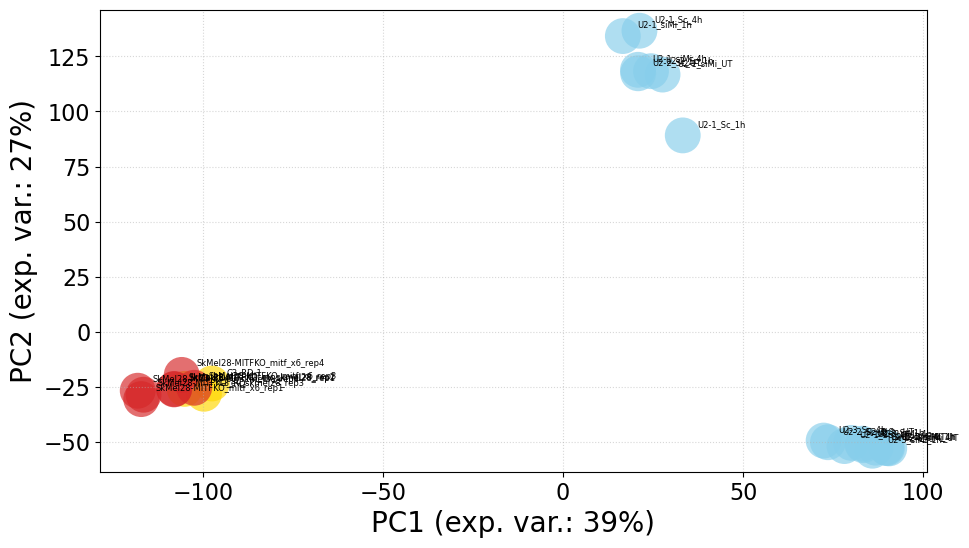

In [11]:
for i in range(len(new)):

    # colors
    if 'SkMel28' in expression.columns[i]:
        the_color = 'tab:red'
    elif 'C3_RD' in expression.columns[i]:
        the_color = 'gold'
    elif 'U2' in expression.columns[i]:
        the_color = 'skyblue'
    else:
        the_color = 'black'
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 4
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=6)

    if 'U2' in expression.columns[i]:
        
        if new[i, 1] > 25:
            print(expression.columns[i])
        else:
            print('\t', expression.columns[i])

#matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [12]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.41937459 0.2904014 ]


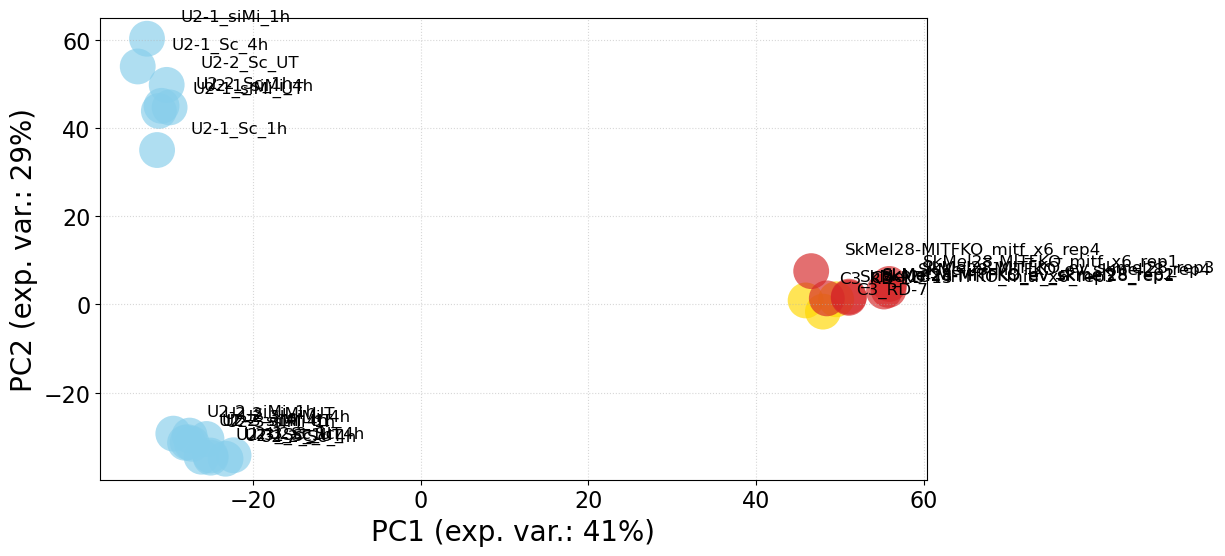

In [13]:
for i in range(len(new)):
    #matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=my_colors[i], marker=my_markers[i], alpha=2/3, edgecolors='none')
    # colors
    if 'SkMel28' in expression.columns[i]:
        the_color = 'tab:red'
    elif 'C3_RD' in expression.columns[i]:
        the_color = 'gold'
    elif 'U2' in expression.columns[i]:
        the_color = 'skyblue'
    else:
        the_color = 'black'
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=666, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 4
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, expression.columns[i], size=12)
#matplotlib.pyplot.legend(legend_elements, ['h1', 'h2 low', 'h2 high', 'KO', 'WT'], ncol=2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(alpha=0.5, ls=':')
matplotlib.pyplot.show()